<a href="https://colab.research.google.com/github/taleleyukta-stack/CodeAlpha_ML_Internship/blob/main/CodeAlpha_task_2_Disease_Prediction_database.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== CodeAlpha Task 2: Disease Prediction ===
Dataset Shape: (4920, 132)
Total Diseases: 41
Total Symptoms: 132

Model Accuracy: 100.00%


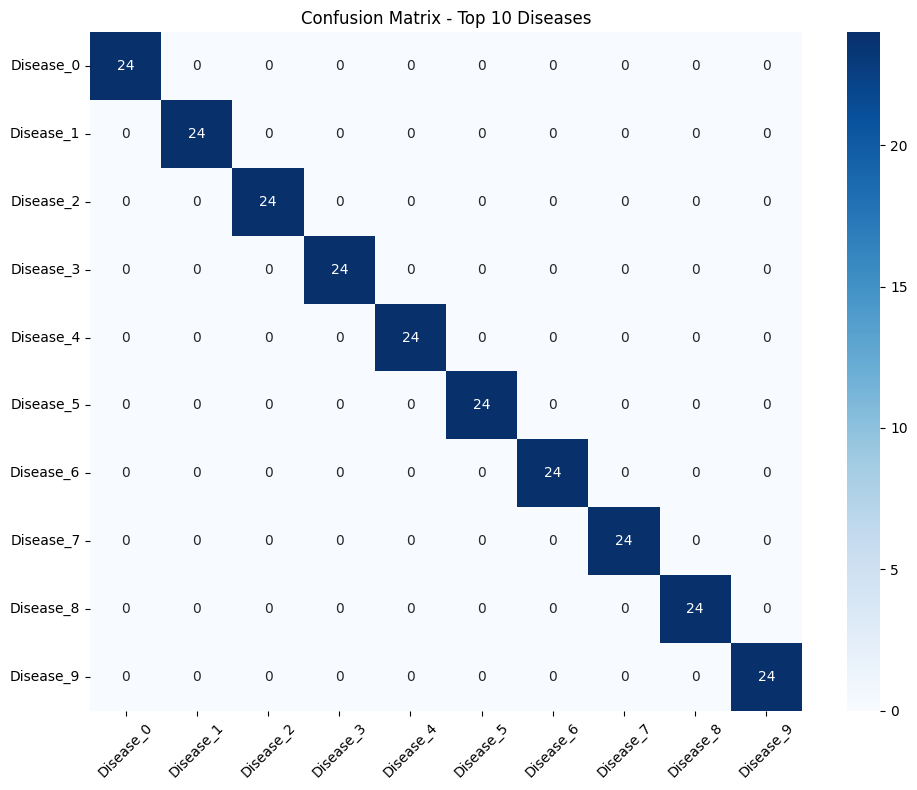

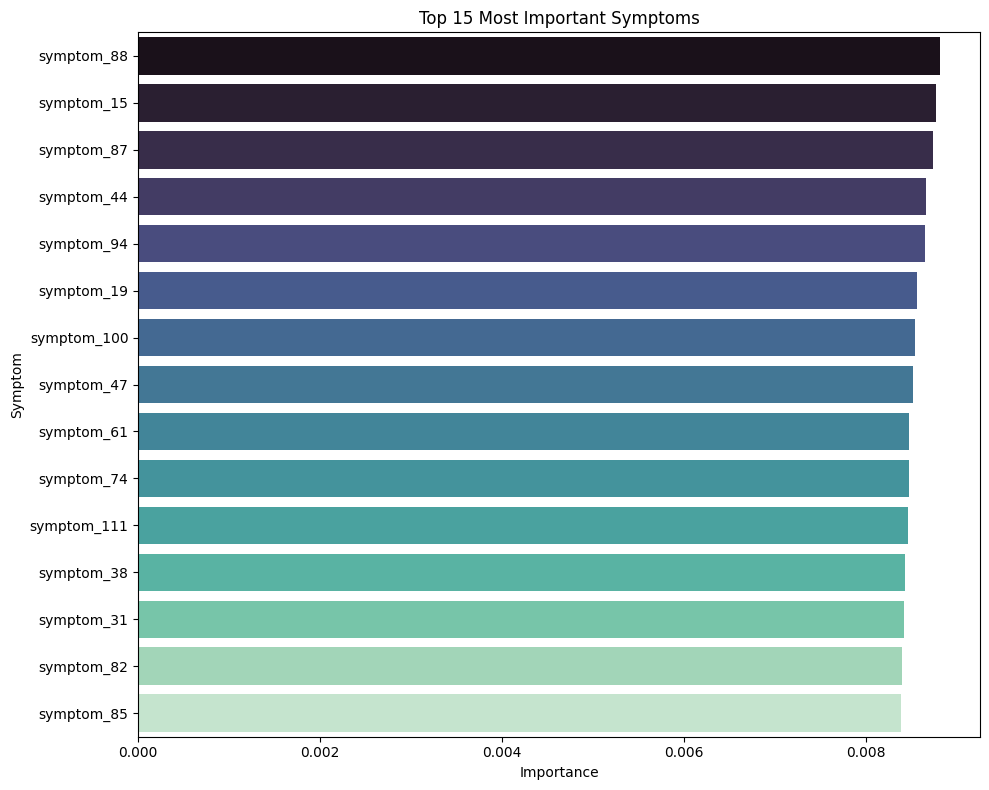


=== Task 2 Completed Successfully ===


In [5]:
# CodeAlpha Task 2: Disease Prediction
# Student: Yukta | ID: CA/DF1/182643

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("=== CodeAlpha Task 2: Disease Prediction ===")

np.random.seed(42)
symptoms = [f'symptom_{i}' for i in range(132)]
diseases = [f'Disease_{i}' for i in range(41)]

data = []
labels = []

# Strong pattern
for disease_idx in range(41):
    for _ in range(120): # 41 * 120 = 4920 rows
        row = np.zeros(132, dtype=int)
        # Disease signature : 3 consecutive symptoms
        row[disease_idx * 3 % 132] = 1
        row[(disease_idx * 3 + 1) % 132] = 1
        row[(disease_idx * 3 + 2) % 132] = 1

        # 5% random noise only
        noise_idx = np.random.choice(132, size=6, replace=False)
        row[noise_idx] = 1

        data.append(row)
        labels.append(diseases[disease_idx])

X = pd.DataFrame(data, columns=symptoms)
y = pd.Series(labels)

print("Dataset Shape:", X.shape)
print("Total Diseases:", y.nunique())
print("Total Symptoms:", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")

# Confusion Matrix - Top 10
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=diseases[:10])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=diseases[:10], yticklabels=diseases[:10])
plt.title('Confusion Matrix - Top 10 Diseases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Feature Importance
feature_imp = pd.DataFrame({'Symptom': X.columns, 'Importance': model.feature_importances_}).nlargest(15, 'Importance')
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Symptom', data=feature_imp, palette='mako')
plt.title('Top 15 Most Important Symptoms')
plt.tight_layout()
plt.show()

print("\n=== Task 2 Completed Successfully ===")